In [1]:
import numpy as np
from tqdm import tqdm
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from model import GalerkinSARIMA
import time
import warnings


In [2]:

warnings.filterwarnings("ignore")
np.random.seed(123)

csv_path = "GDP.csv"
target_col = "GDP"
m_seasonal = 4

def _pick_date_col(df: pd.DataFrame) -> str:
    for c in ["observation_date", "GDP"]:
        if c in df.columns:
            return c
    return df.columns[0]

def _to_stationary(x: pd.Series) -> pd.Series:
    x = x.astype(float)
    if (x > 0).all():
        return (100.0 * np.log(x)).diff().dropna()
    else:
        return x.diff().dropna()

In [3]:

raw = pd.read_csv(csv_path)
date_col = _pick_date_col(raw)
raw[date_col] = pd.to_datetime(raw[date_col], errors="coerce")
raw = raw.set_index(date_col).sort_index()

if target_col not in raw.columns:
    numeric_cols = raw.select_dtypes(include=[np.number]).columns.tolist()
    if not numeric_cols:
        raise ValueError("No numeric columns found in FRED.csv.")
    target_col = numeric_cols[3]

y_level = raw[target_col].dropna()
y = _to_stationary(y_level).replace([np.inf, -np.inf], np.nan).dropna()
series_fred = y.values

# Store the date index corresponding to the series (after differencing/transformation)
# This will be used for plotting with dates on x-axis
date_index_fred = y.index

datasets = {f'FRED_{target_col}': series_fred}
date_indices = {f'FRED_{target_col}': date_index_fred}

In [4]:

window = 60  # Training window size (120 points before testing period)
horizon = 120  # Testing window size (last 120 points)
num_runs = 1

p_values = [0,1]
q_values = [0,1]
P_values = [0,1]
Q_values = [0,1]

orders = [(p, q, P, Q) for p in p_values for q in q_values for P in P_values for Q in Q_values]
forecast_steps = 1

# Rolling window setup: test on last horizon points, train on window points before that
# Test period: indices [len(series) - horizon : len(series)]
# Training period: indices [len(series) - horizon - window : len(series) - horizon]
for name, series in datasets.items():
    if len(series) < window + horizon:
        adjusted_horizon = max(24, len(series) - window)
        print(f"Warning: Adjusted horizon for {name} to {adjusted_horizon} due to insufficient data (have {len(series)} points, need {window + horizon})")
        horizon = adjusted_horizon

In [5]:

all_results = []
first_run_preds = {}  # Store predictions from first run for plotting

# Define algorithms to run
algorithms = [
    {'name': 'GARIMA-OLS', 'use_ridge': False},
    {'name': 'GARIMA-Ridge', 'use_ridge': True, 'ridge_lambda_ar': 1.5, 'ridge_lambda_ma': 1.0, 
     'ridge_weight_scheme': 'poly', 'ridge_eta': 1.5},
    {'name': 'ARIMA', 'is_statsmodels': True},
]

for run in range(1, num_runs + 1):
    runs_left = num_runs - run
    print(f"\n=== Run {run}/{num_runs}  (runs left after this: {runs_left}) ===")
    
    for name, series in datasets.items():
        m = m_seasonal
        n = len(series)
        
        # Rolling window: test on last horizon points
        test_start_idx = n - horizon
        test_end_idx = n
        y_true = series[test_start_idx:test_end_idx]
        
        for p, q, P, Q in tqdm(orders, desc=f"Param combos for {name}", total=len(orders), leave=False):
            # Run each algorithm
            for alg_config in algorithms:
                alg_name = alg_config['name']
                preds = []
                iter_times = []
                
                combo_start = time.perf_counter()
                
                # Rolling window: for each test point, train on window points before it
                for test_idx in range(test_start_idx, test_end_idx):
                    t0 = time.perf_counter()
                    # Train on window points before this test point
                    train_start_idx = max(0, test_idx - window)
                    train = series[train_start_idx:test_idx]
                    
                    try:
                        if alg_config.get('is_statsmodels', False):
                            # ARIMA from statsmodels
                            model = ARIMA(train, order=(p, 0, q))
                            model_fit = model.fit(method_kwargs={"warn_convergence": False})
                            pred_vec = model_fit.forecast(steps=forecast_steps)
                            pred = float(pred_vec[-1])
                        else:
                            # GalerkinSARIMA (OLS or Ridge)
                            model = GalerkinSARIMA(
                                train,
                                order=(p, 0, q),
                                seasonal_order=(P, 0, Q, m),
                                basis_functions=["quadratic", "sigmoid", "linear"],
                                forecast_method="direct",
                                use_ridge=alg_config['use_ridge'],
                                ridge_lambda_ar=alg_config.get('ridge_lambda_ar', 2.0),
                                ridge_lambda_ma=alg_config.get('ridge_lambda_ma', 2.0),
                                ridge_weight_scheme=alg_config.get('ridge_weight_scheme', 'none'),
                                ridge_eta=alg_config.get('ridge_eta', 1.0),
                                standardize=True
                            )
                            model.fit(train)
                            pred_vec = model.forecast(steps=forecast_steps)
                            pred = pred_vec[-1] if np.ndim(pred_vec) > 0 else float(pred_vec)
                        
                        preds.append(float(pred))
                    except Exception as e:
                        # If fitting fails, use last value
                        preds.append(float(train[-1]))
                    
                    iter_times.append(time.perf_counter() - t0)
                
                combo_sec = time.perf_counter() - combo_start
                
                preds = np.asarray(preds, dtype=float)
                
                # Store predictions from first run for plotting
                if run == 1:
                    first_run_preds[(name, p, q, P, Q, alg_name)] = preds
                
                # Calculate metrics
                mask = np.isfinite(y_true) & np.isfinite(preds)
                mae = mean_absolute_error(y_true[mask], preds[mask]) if mask.any() else np.nan
                rmse = np.sqrt(mean_squared_error(y_true[mask], preds[mask])) if mask.any() else np.nan
                
                # Timing stats
                mean_iter_ms = float(np.mean(iter_times)) * 1000 if len(iter_times) else np.nan
                median_iter_ms = float(np.median(iter_times)) * 1000 if len(iter_times) else np.nan
                max_iter_ms = float(np.max(iter_times)) * 1000 if len(iter_times) else np.nan
                throughput = (len(iter_times) / combo_sec) if combo_sec > 0 else np.nan
                
                all_results.append([
                    name, p, q, P, Q, run, alg_name,
                    mae, rmse,
                    mean_iter_ms, median_iter_ms, max_iter_ms,
                    combo_sec, len(iter_times), throughput
                ])

df = pd.DataFrame(
    all_results,
    columns=[
        'Dataset', 'p', 'q', 'P', 'Q', 'Run', 'Alg',
        'MAE', 'RMSE',
        'mean_iter_ms', 'median_iter_ms', 'max_iter_ms',
        'combo_sec', 'num_iters', 'throughput_iters_per_sec'
    ]
)
agg = df.groupby(['Dataset', 'p', 'q', 'P', 'Q', 'Alg'], as_index=False).mean(numeric_only=True)
print("\nAveraged over {} runs (including timing):\n".format(num_runs))
try:
    print(agg.to_markdown(index=False, floatfmt=".4f"))
except Exception:
    print(agg)



=== Run 1/1  (runs left after this: 0) ===



Averaged over 1 runs (including timing):

| Dataset   |   p |   q |   P |   Q | Alg          |    Run |    MAE |   RMSE |   mean_iter_ms |   median_iter_ms |   max_iter_ms |   combo_sec |   num_iters |   throughput_iters_per_sec |
|:----------|----:|----:|----:|----:|:-------------|-------:|-------:|-------:|---------------:|-----------------:|--------------:|------------:|------------:|---------------------------:|
| FRED_GDP  |   0 |   0 |   0 |   0 | ARIMA        | 1.0000 | 0.6633 | 1.3466 |         6.0215 |           5.8175 |       11.1642 |      0.7226 |    120.0000 |                   166.0592 |
| FRED_GDP  |   0 |   0 |   0 |   0 | GARIMA-OLS   | 1.0000 | 0.6633 | 1.3466 |         0.2852 |           0.2630 |        0.8135 |      0.0342 |    120.0000 |                  3504.2508 |
| FRED_GDP  |   0 |   0 |   0 |   0 | GARIMA-Ridge | 1.0000 | 0.6633 | 1.3466 |         0.2797 |           0.2535 |        0.6319 |      0.0336 |    120.0000 |                  3572.9217 |
| FRED_GDP  

In [6]:
best_results = pd.concat([
    agg.groupby(['Dataset', 'Alg']).apply(lambda x: x.loc[x['MAE'].idxmin()]).assign(Metric='Best MAE'),
    agg.groupby(['Dataset', 'Alg']).apply(lambda x: x.loc[x['RMSE'].idxmin()]).assign(Metric='Best RMSE')
])

best_results

Dataset  p  q  P  Q           Alg  Run       MAE  \
Dataset  Alg                                                               
FRED_GDP ARIMA         FRED_GDP  0  0  0  0         ARIMA  1.0  0.663297   
         GARIMA-OLS    FRED_GDP  0  0  0  0    GARIMA-OLS  1.0  0.663297   
         GARIMA-Ridge  FRED_GDP  0  0  0  0  GARIMA-Ridge  1.0  0.663297   
         ARIMA         FRED_GDP  0  0  0  0         ARIMA  1.0  0.663297   
         GARIMA-OLS    FRED_GDP  0  0  0  0    GARIMA-OLS  1.0  0.663297   
         GARIMA-Ridge  FRED_GDP  0  0  0  0  GARIMA-Ridge  1.0  0.663297   

                           RMSE  mean_iter_ms  median_iter_ms  max_iter_ms  \
Dataset  Alg                                                                 
FRED_GDP ARIMA         1.346568      6.021473        5.817458    11.164167   
         GARIMA-OLS    1.346568      0.285154        0.262958     0.813542   
         GARIMA-Ridge  1.346568      0.279688        0.253541     0.631875   
         ARIMA         1.346568      6.021473        5.817458    11.164167   
         GARIMA-OLS    1.346568      0.285154        0.262958     0.813542   
         GARIMA-Ridge  1.346568      0.279688        0.253541     0.631875   

                       combo_sec  num_iters  throughput_iters_per_sec  \
Dataset  Alg                                                            
FRED_GDP ARIMA          0.722634      120.0                166.059224   
         GARIMA-OLS     0.034244      120.0               3504.250752   
         GARIMA-Ridge   0.033586      120.0               3572.921736   
         ARIMA          0.722634      120.0                166.059224   
         GARIMA-OLS     0.034244      120.0               3504.250752   
         GARIMA-Ridge   0.033586      120.0               3572.921736   

                          Metric  
Dataset  Alg                      
FRED_GDP ARIMA          Best MAE  
         GARIMA-OLS     Best MAE  
         GARIMA-Ridge   Best MAE  
         ARIMA         Best RMSE  
         GARIMA-OLS    Best RMSE  
         GARIMA-Ridge  Best RMSE

Saved: GDP_comparison_plots/FRED_GDP_p0_q0_P0_Q0_m4.png


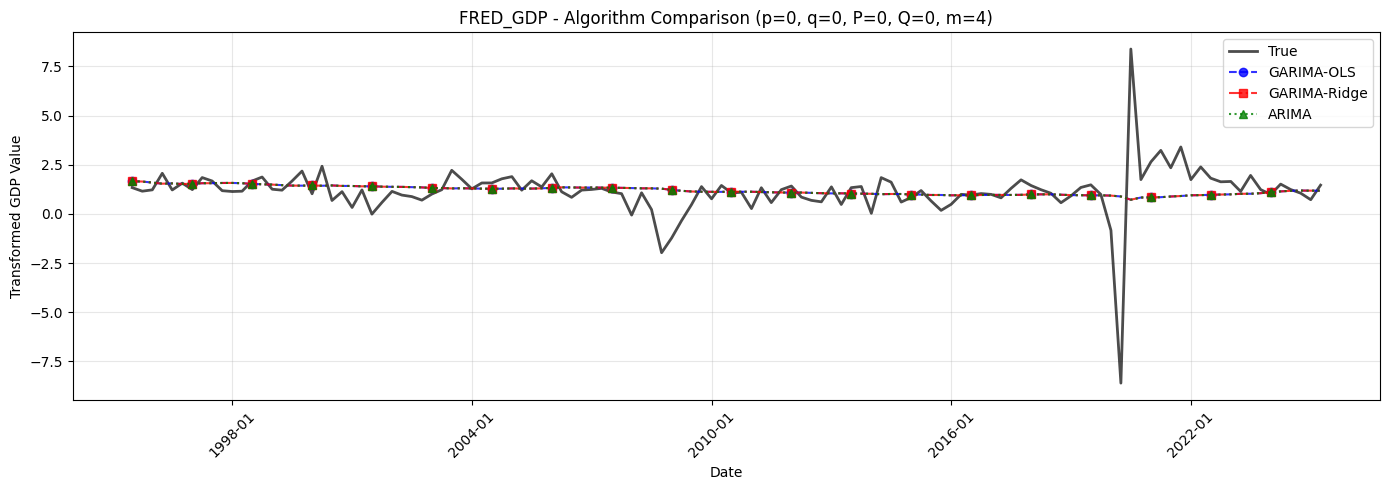


FRED_GDP (p=0, q=0, P=0, Q=0):
  ARIMA           - MAE: 0.6633, RMSE: 1.3466, Time: 0.72s
  GARIMA-OLS      - MAE: 0.6633, RMSE: 1.3466, Time: 0.03s
  GARIMA-Ridge    - MAE: 0.6633, RMSE: 1.3466, Time: 0.03s

Saved: GDP_comparison_plots/FRED_GDP_p0_q0_P0_Q1_m4.png


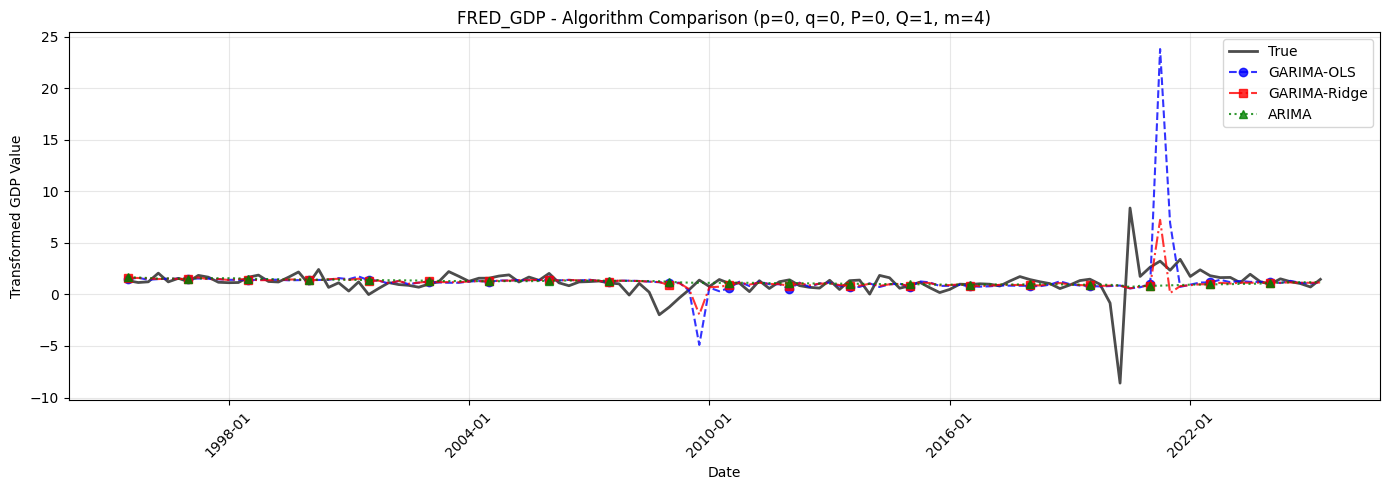


FRED_GDP (p=0, q=0, P=0, Q=1):
  ARIMA           - MAE: 0.6633, RMSE: 1.3466, Time: 0.73s
  GARIMA-OLS      - MAE: 0.8948, RMSE: 2.4075, Time: 0.06s
  GARIMA-Ridge    - MAE: 0.6976, RMSE: 1.4158, Time: 0.08s

Saved: GDP_comparison_plots/FRED_GDP_p0_q0_P1_Q0_m4.png


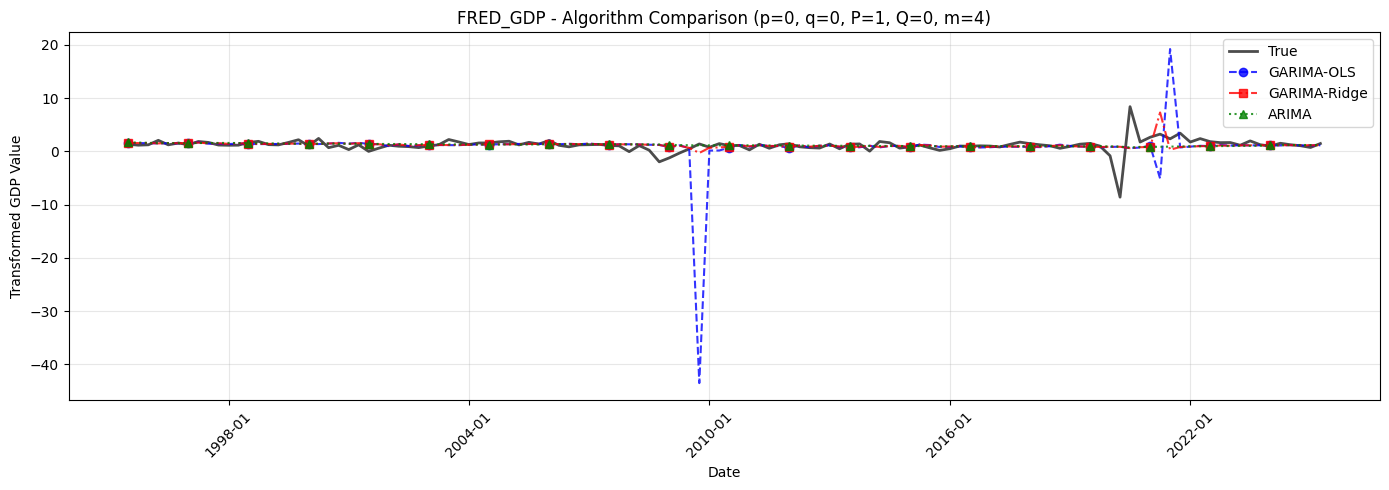


FRED_GDP (p=0, q=0, P=1, Q=0):
  ARIMA           - MAE: 0.6633, RMSE: 1.3466, Time: 0.74s
  GARIMA-OLS      - MAE: 1.2223, RMSE: 4.6379, Time: 0.04s
  GARIMA-Ridge    - MAE: 0.6855, RMSE: 1.3911, Time: 0.05s

Saved: GDP_comparison_plots/FRED_GDP_p0_q0_P1_Q1_m4.png


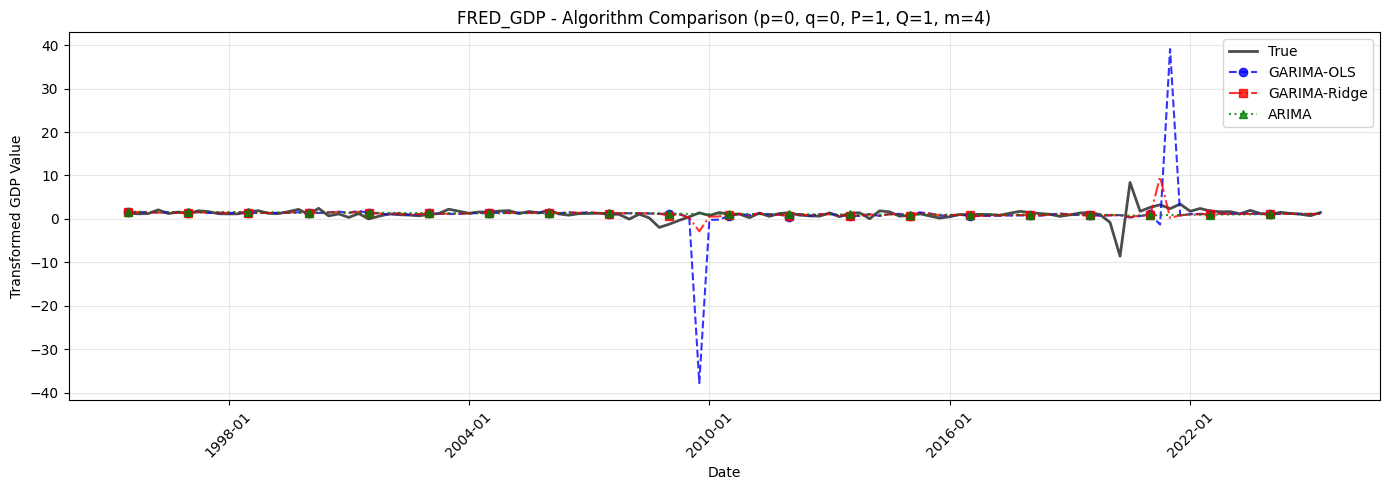


FRED_GDP (p=0, q=0, P=1, Q=1):
  ARIMA           - MAE: 0.6633, RMSE: 1.3466, Time: 0.73s
  GARIMA-OLS      - MAE: 1.3245, RMSE: 5.1061, Time: 0.08s
  GARIMA-Ridge    - MAE: 0.7307, RMSE: 1.5124, Time: 0.09s

Saved: GDP_comparison_plots/FRED_GDP_p0_q1_P0_Q0_m4.png


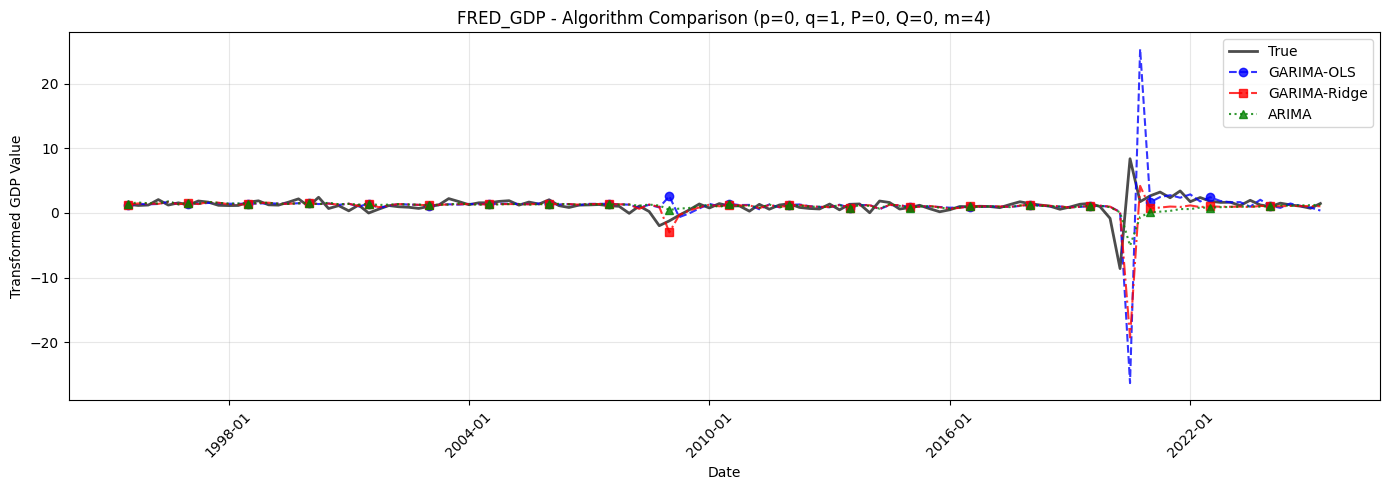


FRED_GDP (p=0, q=1, P=0, Q=0):
  ARIMA           - MAE: 0.7288, RMSE: 1.6762, Time: 0.75s
  GARIMA-OLS      - MAE: 1.0353, RMSE: 3.9765, Time: 0.08s
  GARIMA-Ridge    - MAE: 0.8118, RMSE: 2.7491, Time: 0.09s

Saved: GDP_comparison_plots/FRED_GDP_p0_q1_P0_Q1_m4.png


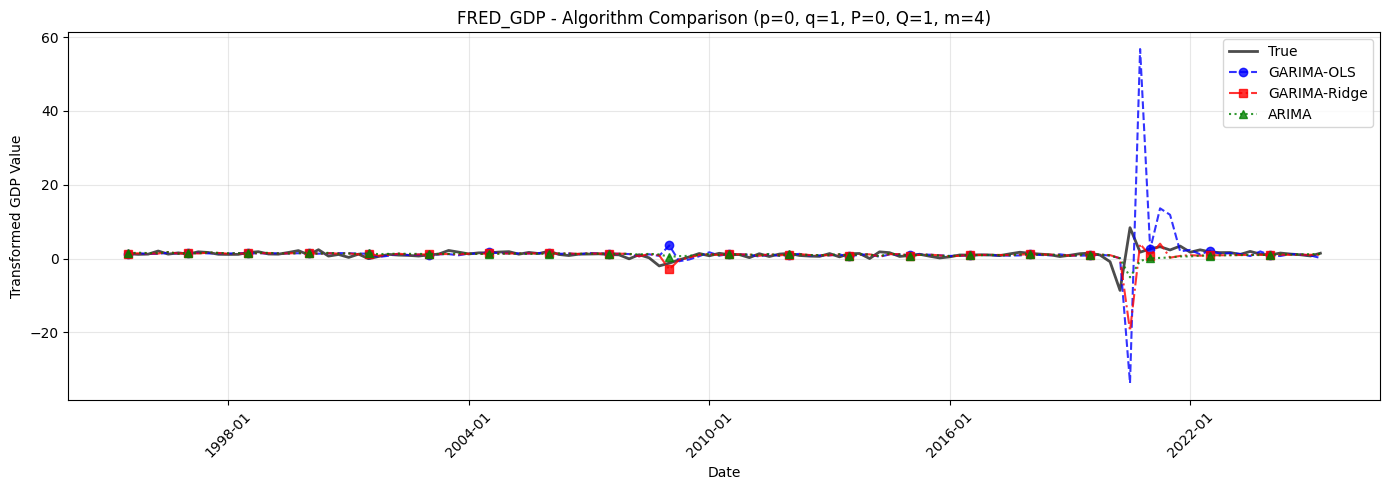


FRED_GDP (p=0, q=1, P=0, Q=1):
  ARIMA           - MAE: 0.7288, RMSE: 1.6762, Time: 0.73s
  GARIMA-OLS      - MAE: 1.5313, RMSE: 6.5479, Time: 0.09s
  GARIMA-Ridge    - MAE: 0.8056, RMSE: 2.7710, Time: 0.31s

Saved: GDP_comparison_plots/FRED_GDP_p0_q1_P1_Q0_m4.png


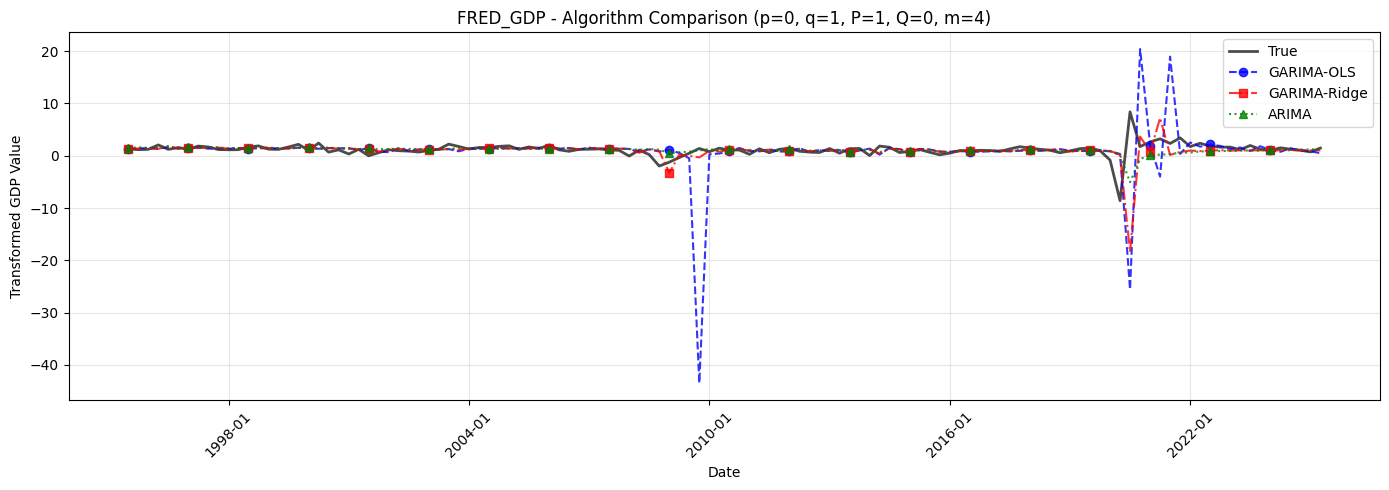


FRED_GDP (p=0, q=1, P=1, Q=0):
  ARIMA           - MAE: 0.7288, RMSE: 1.6762, Time: 0.76s
  GARIMA-OLS      - MAE: 1.5725, RMSE: 5.7596, Time: 0.09s
  GARIMA-Ridge    - MAE: 0.8447, RMSE: 2.7048, Time: 0.10s

Saved: GDP_comparison_plots/FRED_GDP_p0_q1_P1_Q1_m4.png


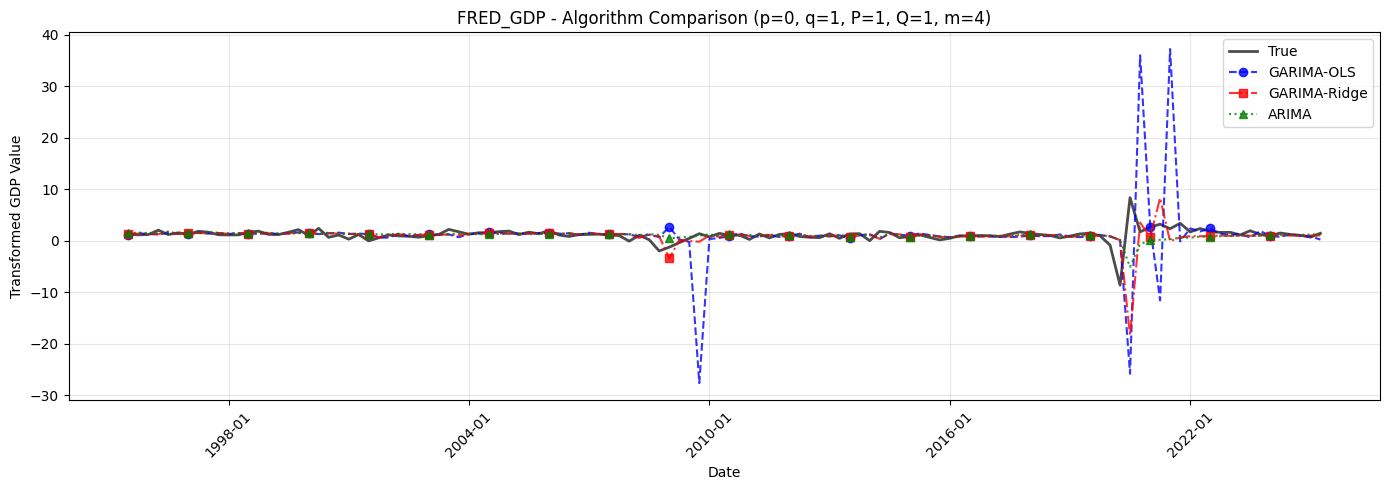


FRED_GDP (p=0, q=1, P=1, Q=1):
  ARIMA           - MAE: 0.7288, RMSE: 1.6762, Time: 0.83s
  GARIMA-OLS      - MAE: 1.7932, RMSE: 6.3047, Time: 0.10s
  GARIMA-Ridge    - MAE: 0.8546, RMSE: 2.7205, Time: 0.14s

Saved: GDP_comparison_plots/FRED_GDP_p1_q0_P0_Q0_m4.png


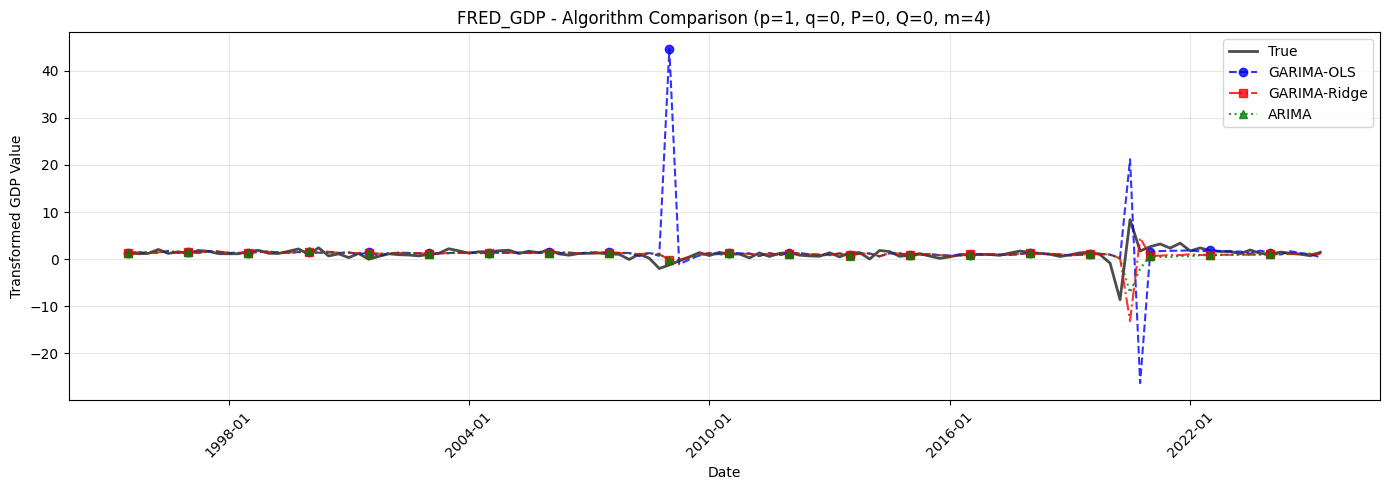


FRED_GDP (p=1, q=0, P=0, Q=0):
  ARIMA           - MAE: 0.7377, RMSE: 1.8186, Time: 0.73s
  GARIMA-OLS      - MAE: 1.2445, RMSE: 5.1465, Time: 0.05s
  GARIMA-Ridge    - MAE: 0.7632, RMSE: 2.2550, Time: 0.06s

Saved: GDP_comparison_plots/FRED_GDP_p1_q0_P0_Q1_m4.png


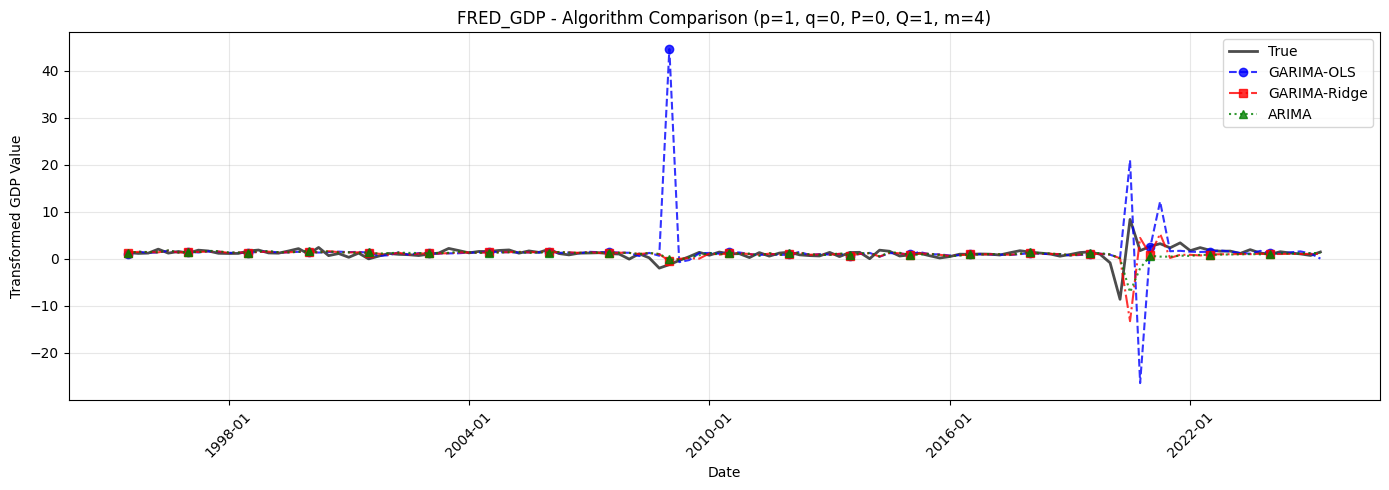


FRED_GDP (p=1, q=0, P=0, Q=1):
  ARIMA           - MAE: 0.7377, RMSE: 1.8186, Time: 0.72s
  GARIMA-OLS      - MAE: 1.3055, RMSE: 5.2076, Time: 0.09s
  GARIMA-Ridge    - MAE: 0.7727, RMSE: 2.2629, Time: 0.10s

Saved: GDP_comparison_plots/FRED_GDP_p1_q0_P1_Q0_m4.png


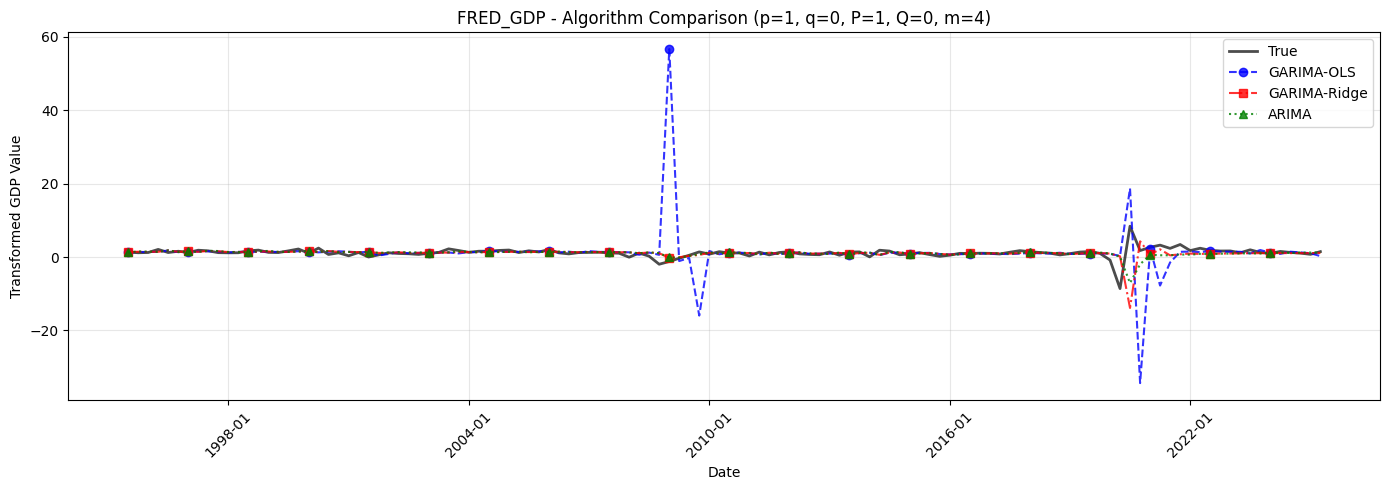


FRED_GDP (p=1, q=0, P=1, Q=0):
  ARIMA           - MAE: 0.7377, RMSE: 1.8186, Time: 0.73s
  GARIMA-OLS      - MAE: 1.6482, RMSE: 6.6582, Time: 0.06s
  GARIMA-Ridge    - MAE: 0.7619, RMSE: 2.3071, Time: 0.10s

Saved: GDP_comparison_plots/FRED_GDP_p1_q0_P1_Q1_m4.png


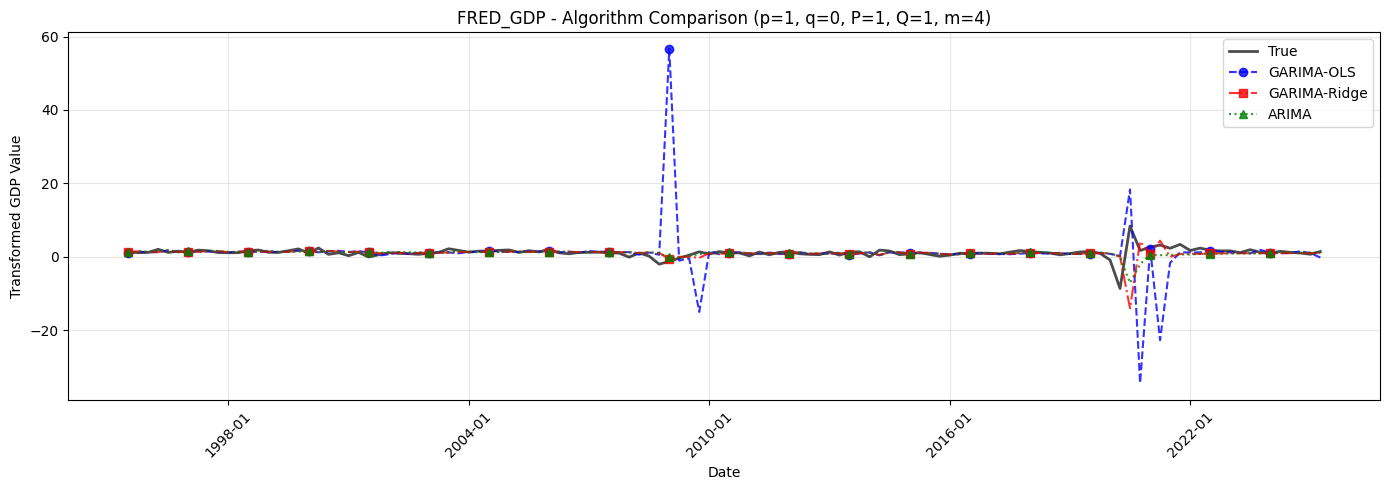


FRED_GDP (p=1, q=0, P=1, Q=1):
  ARIMA           - MAE: 0.7377, RMSE: 1.8186, Time: 0.69s
  GARIMA-OLS      - MAE: 1.7819, RMSE: 6.9692, Time: 0.10s
  GARIMA-Ridge    - MAE: 0.7760, RMSE: 2.3199, Time: 0.14s

Saved: GDP_comparison_plots/FRED_GDP_p1_q1_P0_Q0_m4.png


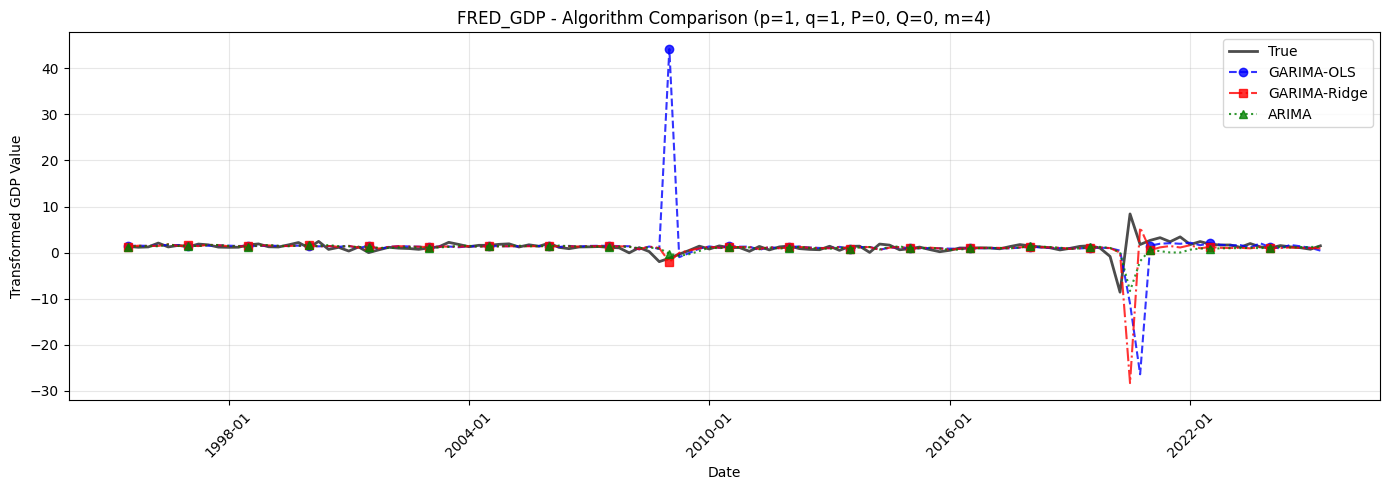


FRED_GDP (p=1, q=1, P=0, Q=0):
  ARIMA           - MAE: 0.7619, RMSE: 1.9181, Time: 1.38s
  GARIMA-OLS      - MAE: 1.3070, RMSE: 5.2929, Time: 0.09s
  GARIMA-Ridge    - MAE: 0.8798, RMSE: 3.5266, Time: 0.11s

Saved: GDP_comparison_plots/FRED_GDP_p1_q1_P0_Q1_m4.png


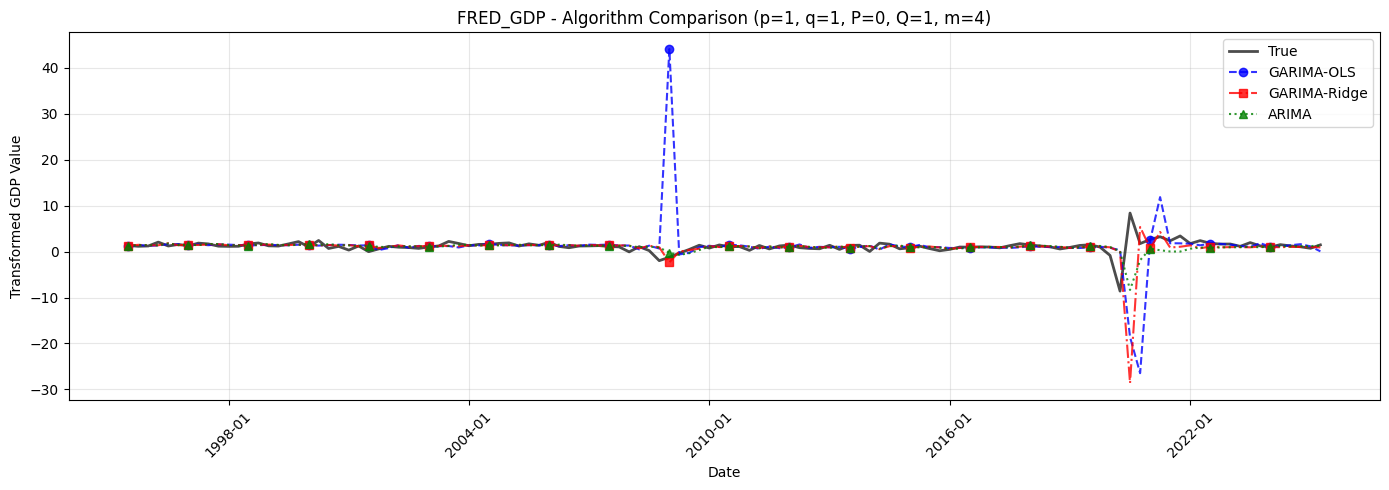


FRED_GDP (p=1, q=1, P=0, Q=1):
  ARIMA           - MAE: 0.7619, RMSE: 1.9181, Time: 1.39s
  GARIMA-OLS      - MAE: 1.4244, RMSE: 5.6092, Time: 0.11s
  GARIMA-Ridge    - MAE: 0.8871, RMSE: 3.5489, Time: 0.14s

Saved: GDP_comparison_plots/FRED_GDP_p1_q1_P1_Q0_m4.png


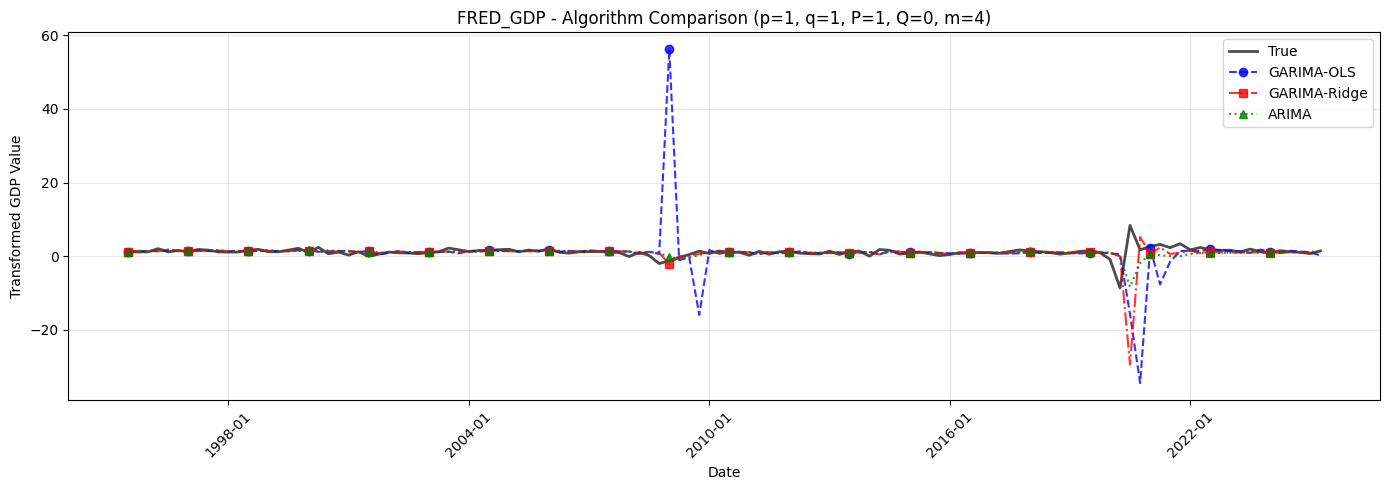


FRED_GDP (p=1, q=1, P=1, Q=0):
  ARIMA           - MAE: 0.7619, RMSE: 1.9181, Time: 1.50s
  GARIMA-OLS      - MAE: 1.7618, RMSE: 6.9258, Time: 0.11s
  GARIMA-Ridge    - MAE: 0.8859, RMSE: 3.6205, Time: 0.13s

Saved: GDP_comparison_plots/FRED_GDP_p1_q1_P1_Q1_m4.png


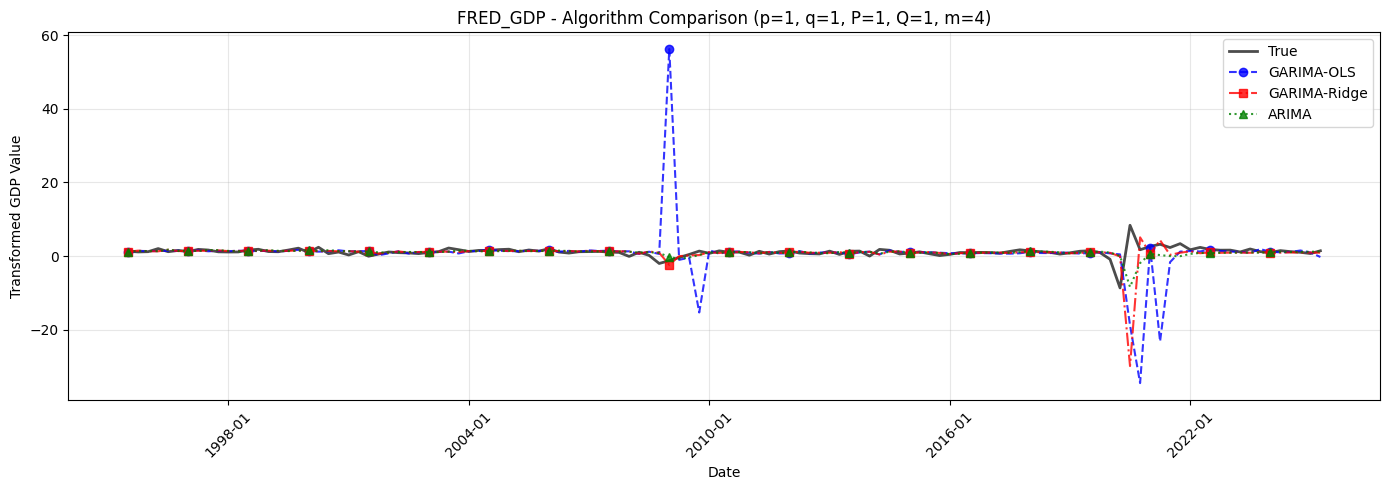


FRED_GDP (p=1, q=1, P=1, Q=1):
  ARIMA           - MAE: 0.7619, RMSE: 1.9181, Time: 1.40s
  GARIMA-OLS      - MAE: 1.9252, RMSE: 7.3352, Time: 0.12s
  GARIMA-Ridge    - MAE: 0.9016, RMSE: 3.6524, Time: 0.21s



In [7]:
import os
import matplotlib.dates as mdates

# Create folder for plots if it doesn't exist
plot_dir = "GDP_comparison_plots"
os.makedirs(plot_dir, exist_ok=True)

# Plot comparison of all three algorithms
for name, series in datasets.items():
    n = len(series)
    # Rolling window: test on last horizon points
    test_start_idx = n - horizon
    test_end_idx = n
    
    # Get dates for the test period
    date_index = date_indices[name]
    test_dates = date_index[test_start_idx:test_end_idx]
    y_true = series[test_start_idx:test_end_idx]
    
    for p, q, P, Q in orders:
        plt.figure(figsize=(14, 5))
        plt.plot(test_dates, y_true, 'k-', linewidth=2, label='True', alpha=0.7)
        
        # Plot each algorithm if it ran successfully
        colors = {'GARIMA-OLS': 'blue', 'GARIMA-Ridge': 'red', 'ARIMA': 'green'}
        markers = {'GARIMA-OLS': 'o', 'GARIMA-Ridge': 's', 'ARIMA': '^'}
        linestyles = {'GARIMA-OLS': '--', 'GARIMA-Ridge': '-.', 'ARIMA': ':'}
        
        for alg_name in ['GARIMA-OLS', 'GARIMA-Ridge', 'ARIMA']:
            key = (name, p, q, P, Q, alg_name)
            if key in first_run_preds:
                preds = first_run_preds[key]
                plt.plot(test_dates, preds, 
                        color=colors[alg_name], 
                        linestyle=linestyles[alg_name],
                        marker=markers[alg_name],
                        markevery=max(1, horizon//20),  # Show markers at reasonable intervals
                        label=alg_name,
                        alpha=0.8)
        
        plt.title(f"{name} - Algorithm Comparison (p={p}, q={q}, P={P}, Q={Q}, m={m_seasonal})", fontsize=12)
        plt.xlabel("Date")
        plt.ylabel("Transformed GDP Value")
        plt.legend(loc='best')
        plt.grid(True, alpha=0.3)
        
        # Format x-axis dates
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        year_interval = max(1, horizon // 20)
        plt.gca().xaxis.set_major_locator(mdates.YearLocator(base=year_interval))
        plt.xticks(rotation=45)
        plt.tight_layout()

        plot_filename = f"{plot_dir}/{name}_p{p}_q{q}_P{P}_Q{Q}_m{m_seasonal}.png"
        plt.savefig(plot_filename, dpi=150, bbox_inches='tight')
        print(f"Saved: {plot_filename}")

        plt.show()
        
        # Print error metrics for this parameter combo
        print(f"\n{name} (p={p}, q={q}, P={P}, Q={Q}):")
        subset = agg[(agg['Dataset'] == name) & 
                     (agg['p'] == p) & 
                     (agg['q'] == q) & 
                     (agg['P'] == P) & 
                     (agg['Q'] == Q)]
        if not subset.empty:
            for _, row in subset.iterrows():
                print(f"  {row['Alg']:15s} - MAE: {row['MAE']:.4f}, RMSE: {row['RMSE']:.4f}, Time: {row['combo_sec']:.2f}s")
        print()

SUMMARY: Algorithm Comparison for GDP Forecasting

Overall Performance (averaged across all datasets and parameter combinations):
         Alg      MAE     RMSE  combo_sec
       ARIMA 0.722932 1.689891   0.908861
GARIMA-Ridge 0.795127 2.506531   0.117384
  GARIMA-OLS 1.402231 5.326963   0.080933

Saved summary table to: GDP_results/summary_comparison.txt

Best Algorithm Per Dataset (by RMSE):

FRED_GDP:
  Best algorithm: ARIMA
  MAE: 0.7229, RMSE: 1.6899
  All algorithms (sorted by RMSE):
    ARIMA          : MAE=0.7229, RMSE=1.6899 ✓ (Winner)
    GARIMA-Ridge   : MAE=0.7951, RMSE=2.5065   (+48.3% worse)
    GARIMA-OLS     : MAE=1.4022, RMSE=5.3270   (+215.2% worse)

Saved comparison plot to: GDP_results/algorithm_comparison.png


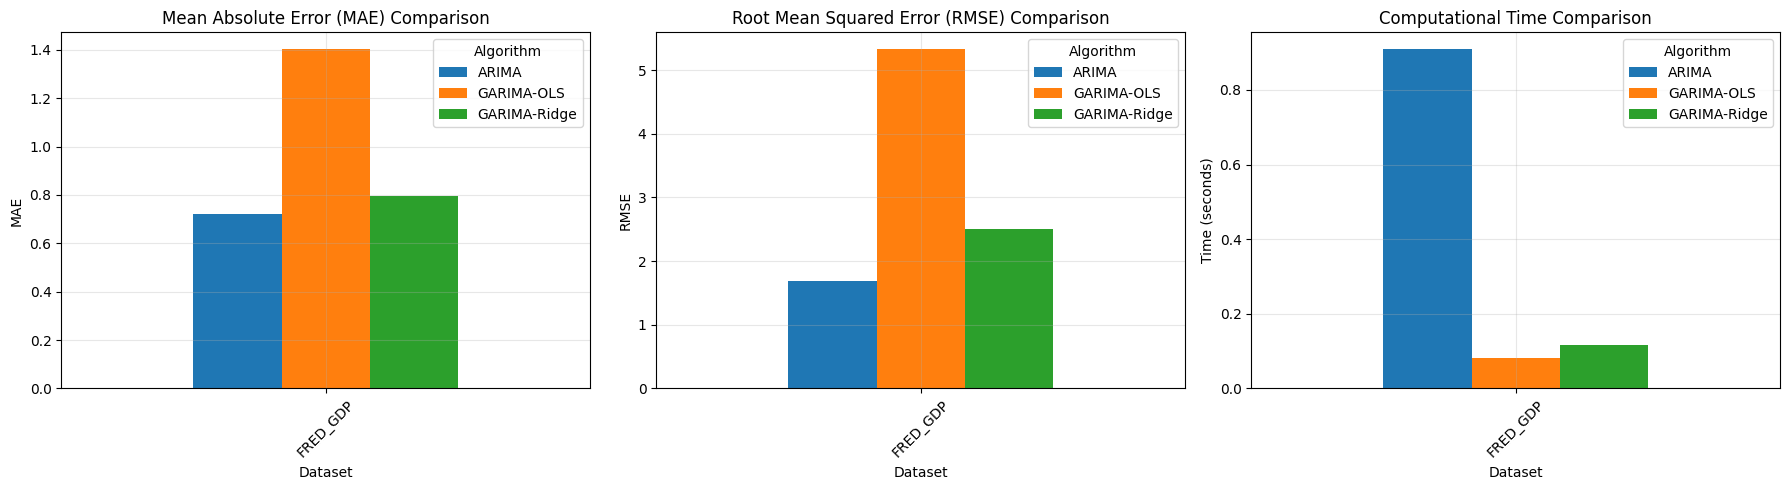


Computational Efficiency:
         Alg  mean_iter_ms  combo_sec  throughput_iters_per_sec
  GARIMA-OLS      0.674258   0.080933               1681.969281
GARIMA-Ridge      0.977953   0.117384               1349.736395
       ARIMA      7.573372   0.908861                143.163720

Saved timing comparison to: GDP_results/timing_comparison.txt


In [8]:
import os

# Summary comparison across all algorithms
print("="*70)
print("SUMMARY: Algorithm Comparison for GDP Forecasting")
print("="*70)

# Check if df exists (from Cell 4)
if 'df' not in locals() and 'df' not in globals():
    raise ValueError("Error: 'df' variable not found. Please run Cell 4 first to create the results DataFrame.")

# Overall average across all datasets
overall = df.groupby('Alg', as_index=False)[['MAE', 'RMSE', 'combo_sec']].mean()
overall = overall.sort_values('RMSE')

print("\nOverall Performance (averaged across all datasets and parameter combinations):")
print(overall.to_string(index=False))

# Save results to GDP-specific directory
results_dir = "GDP_results"
os.makedirs(results_dir, exist_ok=True)

with open(f"{results_dir}/summary_comparison.txt", 'w') as f:
    f.write("Overall Performance (averaged across all datasets and parameter combinations):\n")
    f.write("="*70 + "\n")
    f.write(overall.to_string(index=False))
print(f"\nSaved summary table to: {results_dir}/summary_comparison.txt")

# Best performer per dataset
print("\n" + "="*70)
print("Best Algorithm Per Dataset (by RMSE):")
print("="*70)

for dataset in df['Dataset'].unique():
    dataset_df = df[df['Dataset'] == dataset]
    best = dataset_df.groupby('Alg', as_index=False)[['MAE', 'RMSE']].mean()
    best = best.sort_values('RMSE')
    winner = best.iloc[0]
    
    print(f"\n{dataset}:")
    print(f"  Best algorithm: {winner['Alg']}")
    print(f"  MAE: {winner['MAE']:.4f}, RMSE: {winner['RMSE']:.4f}")
    print(f"  All algorithms (sorted by RMSE):")
    for _, row in best.iterrows():
        # Calculate percentage difference from winner
        if row['Alg'] == winner['Alg']:
            status = "✓ (Winner)"
        else:
            diff_pct = ((row['RMSE'] - winner['RMSE']) / winner['RMSE']) * 100
            status = f"  (+{diff_pct:.1f}% worse)"
        print(f"    {row['Alg']:15s}: MAE={row['MAE']:.4f}, RMSE={row['RMSE']:.4f} {status}")

# Create bar plot comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MAE comparison
mae_pivot = df.groupby(['Dataset', 'Alg'])['MAE'].mean().reset_index().pivot(
    index='Dataset', columns='Alg', values='MAE'
)
mae_pivot.plot(kind='bar', ax=axes[0], rot=45)
axes[0].set_title('Mean Absolute Error (MAE) Comparison')
axes[0].set_ylabel('MAE')
axes[0].legend(title='Algorithm', loc='best')
axes[0].grid(True, alpha=0.3)

# RMSE comparison
rmse_pivot = df.groupby(['Dataset', 'Alg'])['RMSE'].mean().reset_index().pivot(
    index='Dataset', columns='Alg', values='RMSE'
)
rmse_pivot.plot(kind='bar', ax=axes[1], rot=45)
axes[1].set_title('Root Mean Squared Error (RMSE) Comparison')
axes[1].set_ylabel('RMSE')
axes[1].legend(title='Algorithm', loc='best')
axes[1].grid(True, alpha=0.3)

# Timing comparison (computational efficiency)
timing_pivot = df.groupby(['Dataset', 'Alg'])['combo_sec'].mean().reset_index().pivot(
    index='Dataset', columns='Alg', values='combo_sec'
)
timing_pivot.plot(kind='bar', ax=axes[2], rot=45)
axes[2].set_title('Computational Time Comparison')
axes[2].set_ylabel('Time (seconds)')
axes[2].legend(title='Algorithm', loc='best')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()

# Save the comparison plot
comparison_plot_path = f"{results_dir}/algorithm_comparison.png"
plt.savefig(comparison_plot_path, dpi=150, bbox_inches='tight')
print(f"\nSaved comparison plot to: {comparison_plot_path}")
plt.show()

# Timing comparison
print("\n" + "="*70)
print("Computational Efficiency:")
print("="*70)
timing = df.groupby('Alg', as_index=False)[['mean_iter_ms', 'combo_sec', 'throughput_iters_per_sec']].mean()
timing = timing.sort_values('combo_sec')
print(timing.to_string(index=False))

# Save timing comparison
with open(f"{results_dir}/timing_comparison.txt", 'w') as f:
    f.write("Computational Efficiency (averaged across all runs and parameter combinations):\n")
    f.write("="*70 + "\n")
    f.write(timing.to_string(index=False))
print(f"\nSaved timing comparison to: {results_dir}/timing_comparison.txt")
